In [1]:
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
f = "../data/001_raw/ECMWF_utci_20230402_v1.1_con.nc"

utci = xr.open_dataset(f)
utci

<xarray.Dataset> Size: 83MB
Dimensions:  (time: 24, lat: 601, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 192B 2023-04-02 ... 2023-04-02T23:00:00
  * lat      (lat) float64 5kB 90.0 89.75 89.5 89.25 ... -59.5 -59.75 -60.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    utci     (time, lat, lon) float32 83MB ...
Attributes:
    CDI:                       Climate Data Interface version 1.9.10 (https:/...
    Conventions:               CF-1.6
    institution:               European Centre for Medium-Range Weather Forec...
    CDO:                       Climate Data Operators version 1.9.10 (https:/...
    cdo_openmp_thread_number:  8
    history:                   Thu Jun 29 00:17:48 2023: ncatted -a _FillValu...
    NCO:                       netCDF Operators version 4.9.7 (Homepage = htt...

In [3]:
def seleccionar_pais (ds, lat1, lat2, lon1, lon2):
    ds = ds.sel(lat = slice(lat1, lat2), lon= slice(-118, -86))

    return ds

In [4]:
def convertir_a_celsius(ds):
    ds_celsius = ds.copy()
    ds_celsius["utci"] = ds["utci"] - 273.15
    ds_celsius["utci"].attrs["units"] = "°C"
    return ds_celsius

In [13]:
mexico = seleccionar_pais(utci, 33, 14, -118, -86)
mexico = convertir_a_celsius(mexico)

In [14]:
hora = 18
data = mexico["utci"].isel(time=hora).values

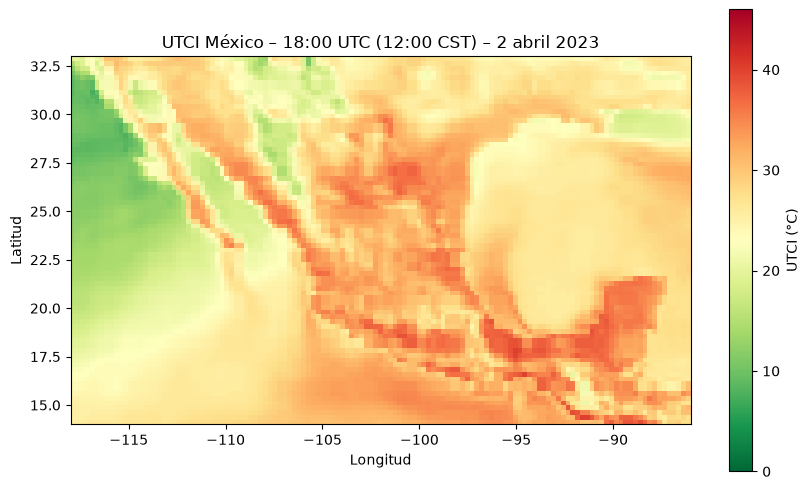

PNG guardado como utci_test.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.imshow(data,
           extent=[-118, -86, 14, 33],
           origin="upper",
           cmap="RdYlGn_r",
           vmin=0, vmax=46)
plt.colorbar(label="UTCI (°C)")
plt.title("UTCI México – 18:00 UTC (12:00 CST) – 2 abril 2023")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.savefig("utci_test.png", dpi=100, bbox_inches="tight")
plt.show()